In [1]:
import os
os.environ["XDG_CACHE_HOME"] = os.path.join(os.environ["CONDA_PREFIX"], ".cache")


import numpy as np
from dolfinx import default_scalar_type, io, plot
from mpi4py import MPI
import gmsh
import ufl


import pyvista
pyvista.set_jupyter_backend("static")
from dolfinx import fem, mesh
from dolfinx.io import gmshio
from dolfinx.fem.petsc import assemble_matrix
from petsc4py import PETSc
from slepc4py import SLEPc

In [2]:
# ------------------------------------------------------------------
# 1) Define resonator parameter
# ------------------------------------------------------------------

E = 150e9        # Young's modulus [Pa]
nu = 0.064       # Poisson's ratio
rho = 2320       # Density [kg/m^3]

mu = E / (2 * (1 + nu))
lambda_ = E * nu / ((1 + nu) * (1 - 2 * nu))

L=85e-6                    # Length of resonator
d=15e-6                     # width of arm
alpha = np.deg2rad(29.5)    # V-angle
t=0.4e-6                    # resonator thickness

num_eigs = 10  # number of desired eigenvalues


# Helper Function for nicer format of frequencies
def format_frequency(freq):
    """Format frequency in Hz, kHz, or MHz for nicer display."""    
    f_kHz = freq / 1e3
    f_MHz = freq / 1e6

    # nicer text format for plot (automatic unit)
    if freq < 1e3:
        f_label = f"{freq:.3f} Hz"
    elif freq < 1e6:
        f_label = f"{f_kHz:.3f} kHz"
    else:
        f_label = f"{f_MHz:.3f} MHz"

    return f_label

In [3]:

# ------------------------------------------------------------------
# 2a) Geometry + mesh of the V-resonato
# ------------------------------------------------------------------


def gmsh_minus_triangle(model: gmsh.model, name: str,
                                  L: float = 85e-6, d: float = 15e-6,
                                  t: float = 0.4e-6,
                                  alpha: float = np.deg2rad(25.9)) -> gmsh.model:

    x1 = (L + d) * np.tan(alpha) + d * np.cos(alpha)
    y1 = L / np.tan(alpha) + d / np.sin(alpha)

    x2 = L * np.tan(alpha)
    y2 = L / np.tan(alpha)

    model.add(name)
    model.setCurrent(name)

    # -------------------------------
    # Outer A shape in plane z = 0
    # -------------------------------
    p1 = model.occ.addPoint(-x1, 0.0, 0.0)
    p2 = model.occ.addPoint( x1, 0.0, 0.0)
    p3 = model.occ.addPoint( 0.0, y1, 0.0)

    l1 = model.occ.addLine(p1, p2)
    l2 = model.occ.addLine(p2, p3)
    l3 = model.occ.addLine(p3, p1)

    loop_outer = model.occ.addCurveLoop([l1, l2, l3])
    surf_outer = model.occ.addPlaneSurface([loop_outer])

    # Inner triangle (hole)
    p1i = model.occ.addPoint(-x2, 0.0, 0.0)
    p2i = model.occ.addPoint( x2, 0.0, 0.0)
    p3i = model.occ.addPoint( 0.0, y2, 0.0)

    l1i = model.occ.addLine(p1i, p2i)
    l2i = model.occ.addLine(p2i, p3i)
    l3i = model.occ.addLine(p3i, p1i)

    loop_inner = model.occ.addCurveLoop([l1i, l2i, l3i])
    surf_inner = model.occ.addPlaneSurface([loop_inner])

    model.occ.synchronize()

    # -------------------------------
    # Extrude A surfaces and base to 3D
    # -------------------------------
    ext_outer = model.occ.extrude([(2, surf_outer)], 0, 0, t)
    ext_inner = model.occ.extrude([(2, surf_inner)], 0, 0, t)
    model.occ.synchronize()

    outer_vol = [e[1] for e in ext_outer if e[0] == 3][0]
    inner_vol = [e[1] for e in ext_inner if e[0] == 3][0]

    # Boolean operations: A minus inner triangle, then fuse with base
    cut_result = model.occ.cut([(3, outer_vol)], [(3, inner_vol)])
    v_vol = cut_result[0][0][1]   # resulting A volume
    model.occ.synchronize()

    # -------------------------------
    # Physical groups
    # -------------------------------

    # Volumes
    model.addPhysicalGroup(3, [v_vol], tag=1)
    model.setPhysicalName(3, 1, "V_resonator")

    # Mesh erzeugen
    model.mesh.generate(3)
    return model

In [4]:
# ------------------------------------------------------------------
# 2b) Geometry: ONLY V-resonator (without base block)
# ------------------------------------------------------------------


def gmsh_v_resonator_only(model, name,
                          L=195e-6, d=15e-6,
                          alpha = np.deg2rad(29.5),  # used only as starting y-coordinate for the anchor line
                          t=0.4e-6):
    """
    Create a pure V-shaped cantilever (without base block) in a given gmsh model.

    Parameters
    ----------
    model : gmsh.model
        Gmsh model to which the geometry is added.
    name : str
        Name of the CAD model inside gmsh.
    L : float
        Effective length of each leg of the V (m).
    w : float
        Width of the cantilever at the clamped side (m).
    base_h : float
        y-offset for the clamped edge (just a vertical shift of the V, in m).
    t : float
        Thickness of the resonator in z-direction (m).
    alpha : float
        Half opening angle of the V (in radians).
    """
    print(f"V-Resonator=> Length = {L}, d = {d}, alpha = {np.rad2deg(alpha)} deg, thickness = {t}")
    # Clean restart: if a model with this name already exists, delete it
    if name in model.list():
        model.setCurrent(name)
        model.remove()

    # Create and activate new CAD model
    model.add(name)
    model.setCurrent(name)

    # 1) Helper geometry: coordinates of outer and inner triangles
    x1 = (L + d) * np.tan(alpha) + d * np.cos(alpha)
    y1 = L / np.tan(alpha) + d / np.sin(alpha)
    x2 = L * np.tan(alpha)
    y2 = L / np.tan(alpha)

    # 2) 2D surfaces (V-shape)
    # We keep the origin of the clamping line at y = base_h
    # so that we know exactly where to apply the boundary conditions later.

    # --- Outer contour of the V ---
    p1 = model.occ.addPoint(-x1, 0.0, 0.0)
    p2 = model.occ.addPoint( x1, 0.0, 0.0)
    p3 = model.occ.addPoint( 0.0, y1, 0.0)

    # l1 is the "back wall" (clamping line)
    l1 = model.occ.addLine(p1, p2)
    l2 = model.occ.addLine(p2, p3)
    l3 = model.occ.addLine(p3, p1)

    loop_outer = model.occ.addCurveLoop([l1, l2, l3])
    surf_outer = model.occ.addPlaneSurface([loop_outer])

    # --- Inner triangle (cut-out) ---
    p1i = model.occ.addPoint(-x2, 0.0, 0.0)
    p2i = model.occ.addPoint( x2, 0.0, 0.0)
    p3i = model.occ.addPoint( 0.0, y2 + 0.0, 0.0)

    l1i = model.occ.addLine(p1i, p2i)
    l2i = model.occ.addLine(p2i, p3i)
    l3i = model.occ.addLine(p3i, p1i)

    loop_inner = model.occ.addCurveLoop([l1i, l2i, l3i])
    surf_inner = model.occ.addPlaneSurface([loop_inner])

    # Synchronize CAD kernel with gmsh model
    model.occ.synchronize()

    # 3) Boolean cut: V-surface = outer triangle minus inner triangle
    surf_v_cut = model.occ.cut([(2, surf_outer)], [(2, surf_inner)])
    surf_v_tag = surf_v_cut[0][0][1]

    # Extrude the 2D V-surface in z-direction to obtain a 3D volume
    ext_v = model.occ.extrude([(2, surf_v_tag)], 0, 0, t)

    # Extract the created volume entity (dim = 3)
    vol_v = [e[1] for e in ext_v if e[0] == 3][0]

    model.occ.synchronize()

    # 4) Physical groups
    # We now have just one volume, so no fuse operation is needed.
    model.addPhysicalGroup(3, [vol_v], tag=1, name="Resonator_Volume")

    # Optionally: tag all surfaces of the resonator (useful for BCs/postprocessing)
    surfs = model.getEntities(dim=2)
    model.addPhysicalGroup(2, [s[1] for s in surfs], tag=1, name="Surfaces")

    return vol_v


In [5]:
# ------------------------------------------------------------------
# 3) generate mesh and import into Dolfinx
# ------------------------------------------------------------------

# start Gmsh
if not gmsh.is_initialized():
    gmsh.initialize()

gmsh_model = gmsh.model
# call function to create V-resonator geometry
gmsh_v_resonator_only(gmsh_model, "V_resonator", L = L, d = d, alpha = alpha, t = t)

mesh_size_max = 1.63e-6

# mesh options (Feinheit)
gmsh.option.setNumber("Mesh.MeshSizeMin", 1e-8)
gmsh.option.setNumber("Mesh.MeshSizeMax", mesh_size_max)

# generate mesh
gmsh_model.mesh.generate(3)

# Import in Dolfinx
mesh_data = gmshio.model_to_mesh(gmsh_model, MPI.COMM_WORLD, 0, gdim=3)

#domain = mesh_data.mesh
#print(f"Mesh succesfully generated! Number of nodes: {domain.geometry.x.shape[0]}")

V-Resonator=> Length = 8.5e-05, d = 1.5e-05, alpha = 29.500000000000004 deg, thickness = 4e-07
Info    : Meshing 1D...                                                                                                   
Info    : [  0%] Meshing curve 5 (Line)
Info    : [ 10%] Meshing curve 6 (Line)
Info    : [ 20%] Meshing curve 7 (Line)
Info    : [ 20%] Meshing curve 8 (Line)
Info    : [ 30%] Meshing curve 9 (Line)
Info    : [ 30%] Meshing curve 10 (Line)
Info    : [ 40%] Meshing curve 11 (Line)
Info    : [ 40%] Meshing curve 12 (Line)
Info    : [ 50%] Meshing curve 13 (Line)
Info    : [ 60%] Meshing curve 14 (Line)
Info    : [ 60%] Meshing curve 15 (Line)
Info    : [ 70%] Meshing curve 16 (Line)
Info    : [ 70%] Meshing curve 17 (Line)
Info    : [ 80%] Meshing curve 18 (Line)
Info    : [ 80%] Meshing curve 19 (Line)
Info    : [ 90%] Meshing curve 20 (Line)
Info    : [ 90%] Meshing curve 21 (Line)
Info    : [100%] Meshing curve 22 (Line)
Info    : Done meshing 1D (Wall 0.00197508s, CPU 

In [6]:
out = gmshio.model_to_mesh(gmsh_model, MPI.COMM_WORLD, 0, gdim=3)

domain = out[0]
cell_tags = out[1] if len(out) > 1 else None
facet_tags = out[2] if len(out) > 2 else None
edge_tags  = out[3] if len(out) > 3 else None


In [7]:
# ------------------------------------------------------------------
# 4) Boundary Conditions (ROBUST: 0.1nm tolerance)
# ------------------------------------------------------------------
# ------------------------------------------------------------------
# clamped over points (y = 0) +tolerance
# ------------------------------------------------------------------
V = fem.functionspace(domain, ("Lagrange", 1, (domain.geometry.dim,)))

base_start_y = 0.0

fdim = domain.topology.dim - 1

def on_clamped_boundary(x):
    # all points with y-coordinate close to base_start_y
    return np.isclose(x[1], base_start_y, atol=1e-10)

facets_clamped = mesh.locate_entities_boundary(domain, fdim, on_clamped_boundary)
clamped_dofs = fem.locate_dofs_topological(V, fdim, facets_clamped)

u_D = np.zeros(domain.geometry.dim, dtype=default_scalar_type)
bc = fem.dirichletbc(u_D, clamped_dofs, V)

if domain.comm.rank == 0:
    print(f"Number if fixed DOFs: {len(clamped_dofs)}")


Number if fixed DOFs: 60


In [8]:
# ------------------------------------------------------------------
# 5) bilinear forms for elasticity eigenvalue problem
# ------------------------------------------------------------------

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

def eps(u):
    return ufl.sym(ufl.grad(u))

def sigma(u):
    # isotropic linear elasticity
    return 2.0 * mu * eps(u) + lambda_ * ufl.tr(eps(u)) * ufl.Identity(domain.geometry.dim)




In [9]:
jit_options = {"cache_dir": None}

a_form = fem.form(ufl.inner(sigma(u), eps(v)) * ufl.dx, jit_options=jit_options)
m_form = fem.form(rho * ufl.inner(u, v) * ufl.dx, jit_options=jit_options)


ld: warning: duplicate -rpath '/Users/andregesing/miniconda3/envs/fenics2026/lib' ignored
ld: warning: duplicate -rpath '/Users/andregesing/miniconda3/envs/fenics2026/lib' ignored
ld: warning: duplicate -rpath '/Users/andregesing/miniconda3/envs/fenics2026/lib' ignored
ld: warning: duplicate -rpath '/Users/andregesing/miniconda3/envs/fenics2026/lib' ignored


In [10]:
# ------------------------------------------------------------------
# 6) K and M matrices assembly with custom BC handling
# ------------------------------------------------------------------

# Stiffness matrix K (WITH boundary conditions)
K = assemble_matrix(a_form, bcs=[bc])
K.assemble()

# 2. Massenmatrix M (OHNE automatische Randbedingungen)
# Wir bauen M "roh", damit keine 1en auf die Diagonale geschrieben werden.
M = assemble_matrix(m_form) 
M.assemble()

# 3. manually zeroing of the fixed rows in M
# set the complete rows of the clamped DOFs to 0.
# eigenvalue lambda -> infinity (and thus out of the way).
M.zeroRows(clamped_dofs, diag=0.0) 

if domain.comm.rank == 0:
    print(f"Matrix K Size: {K.getSize()}")
    print(f"Matrix M Size: {M.getSize()}")
    print(f"BC-lines in M succesfully zeroed.")

# set symmetry-Flags
K.setOption(PETSc.Mat.Option.SYMMETRIC, True)
M.setOption(PETSc.Mat.Option.SYMMETRIC, True)

# 4. SLEPc Solver Setup
eps = SLEPc.EPS().create(domain.comm)
eps.setOperators(K, M)
eps.setProblemType(SLEPc.EPS.ProblemType.GHEP)
eps.setDimensions(nev=num_eigs) # number of desired modes

# Shift-and-Invert: search for frequencies around 0 Hz (the smallest physical ones)
st = eps.getST()
st.setType(SLEPc.ST.Type.SINVERT)
st.setShift(0.0) 

eps.setWhichEigenpairs(SLEPc.EPS.Which.TARGET_MAGNITUDE)
eps.setTarget(0.0)
eps.setTolerances(tol=1e-9, max_it=10000)
eps.setFromOptions()

print("Start Solver...")
eps.solve()

nconv = eps.getConverged()
if domain.comm.rank == 0:
    print(f"Number converged eigenvalues: {nconv}")

Matrix K Size: (16389, 16389)
Matrix M Size: (16389, 16389)
BC-lines in M succesfully zeroed.
Start Solver...
Number converged eigenvalues: 10


In [11]:
# ------------------------------------------------------------------
# 7) Eigenvalue extraction and postprocessing
# ------------------------------------------------------------------

modes = []
frequencies = []

if nconv == 0:
    if domain.comm.rank == 0:
        print("Keine Eigenwerte konvergiert.")
else:
    u_mode = fem.Function(V)

    # itate over found (nconv) or desired (num_eigs)
    for i in range(min(num_eigs, nconv)):
        lam = eps.getEigenvalue(i)
        lam_real = float(np.real(lam))

        # Negative values or exact 0 (rigid body modes) are often filtered here
        if lam_real <= 0.0:
            if domain.comm.rank == 0:
                print(f"Eigenvalue {i}: λ = {lam_real:.6e} (<= 0, skipped)")
            continue

        omega = np.sqrt(lam_real)
        freq = omega / (2.0 * np.pi)

        # write Eigenvector in u_mode
        xr = u_mode.x.petsc_vec
        eps.getEigenpair(i, xr)
        u_mode.x.scatter_forward()

        # Important: make a copy of the mode, otherwise it will be overwritten
        mode_copy = fem.Function(V)
        mode_copy.x.array[:] = u_mode.x.array

        modes.append((freq, mode_copy))
        frequencies.append(freq)

        f_label = format_frequency(freq)

        if domain.comm.rank == 0:
            print(f"Mode {len(modes):2d}: λ = {lam_real:.6e}, f = {f_label}")

    if domain.comm.rank == 0 and len(modes) == 0:
        print("Es wurden Eigenwerte gefunden, aber alle λ <= 0.")


print("\nPrüfung der Randbedingungen:")
for k, (f, u_k) in enumerate(modes, start=1):
    # Zugriff direkt mit clamped_dofs aus Section 4
    # (Falls clamped_dofs hier rot unterstrichen ist: Section 4 muss ausgeführt sein!)
    vals_clamped = u_k.x.array[clamped_dofs]
    
    max_val = np.max(np.abs(vals_clamped)) if len(vals_clamped) > 0 else 0.0

    f_label = format_frequency(f)
    
    print(f"Mode {k}: f = {f_label}, max|u| on clamped DOFs = {max_val:.3e}")

Mode  1: λ = 3.751017e+11, f = 97.475 kHz
Mode  2: λ = 9.240629e+12, f = 483.806 kHz
Mode  3: λ = 1.022073e+13, f = 508.816 kHz
Mode  4: λ = 6.695973e+13, f = 1.302 MHz
Mode  5: λ = 6.776882e+13, f = 1.310 MHz
Mode  6: λ = 2.082351e+14, f = 2.297 MHz
Mode  7: λ = 2.461144e+14, f = 2.497 MHz
Mode  8: λ = 3.047412e+14, f = 2.778 MHz
Mode  9: λ = 4.887089e+14, f = 3.518 MHz
Mode 10: λ = 5.818340e+14, f = 3.839 MHz

Prüfung der Randbedingungen:
Mode 1: f = 97.475 kHz, max|u| on clamped DOFs = 4.717e+05
Mode 2: f = 483.806 kHz, max|u| on clamped DOFs = 7.660e+05
Mode 3: f = 508.816 kHz, max|u| on clamped DOFs = 5.588e+05
Mode 4: f = 1.302 MHz, max|u| on clamped DOFs = 7.029e+05
Mode 5: f = 1.310 MHz, max|u| on clamped DOFs = 3.501e+05
Mode 6: f = 2.297 MHz, max|u| on clamped DOFs = 8.195e+05
Mode 7: f = 2.497 MHz, max|u| on clamped DOFs = 5.256e+05
Mode 8: f = 2.778 MHz, max|u| on clamped DOFs = 6.659e+05
Mode 9: f = 3.518 MHz, max|u| on clamped DOFs = 6.558e+05
Mode 10: f = 3.839 MHz, max|

Zeige 10 relevante Moden an.


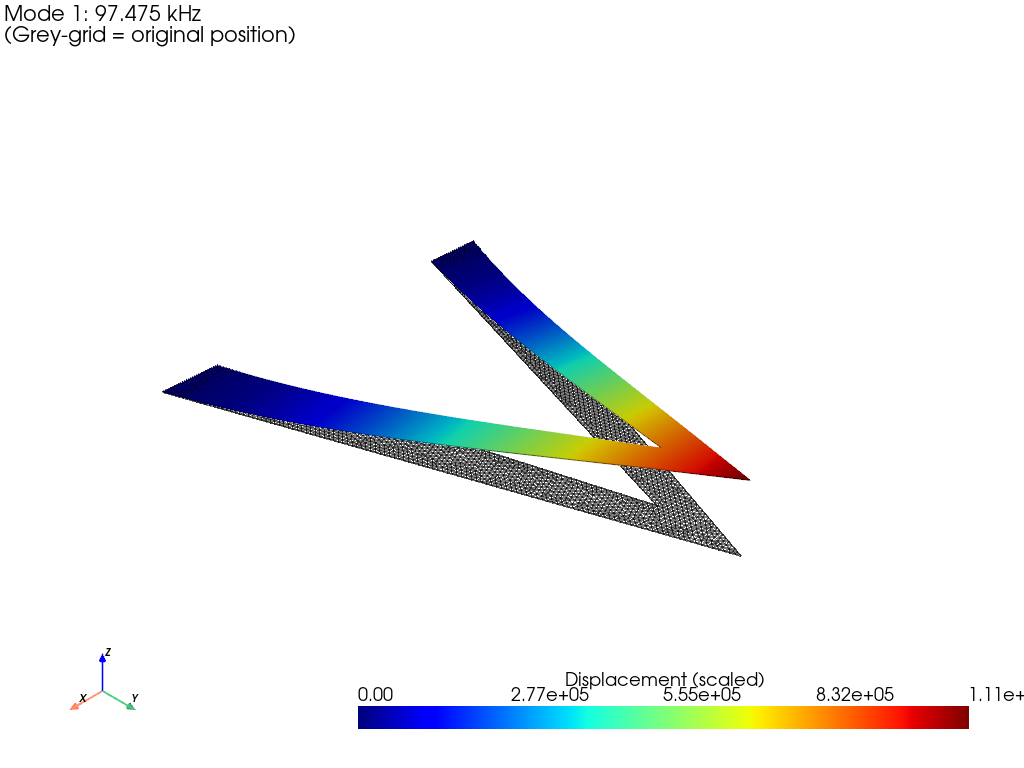

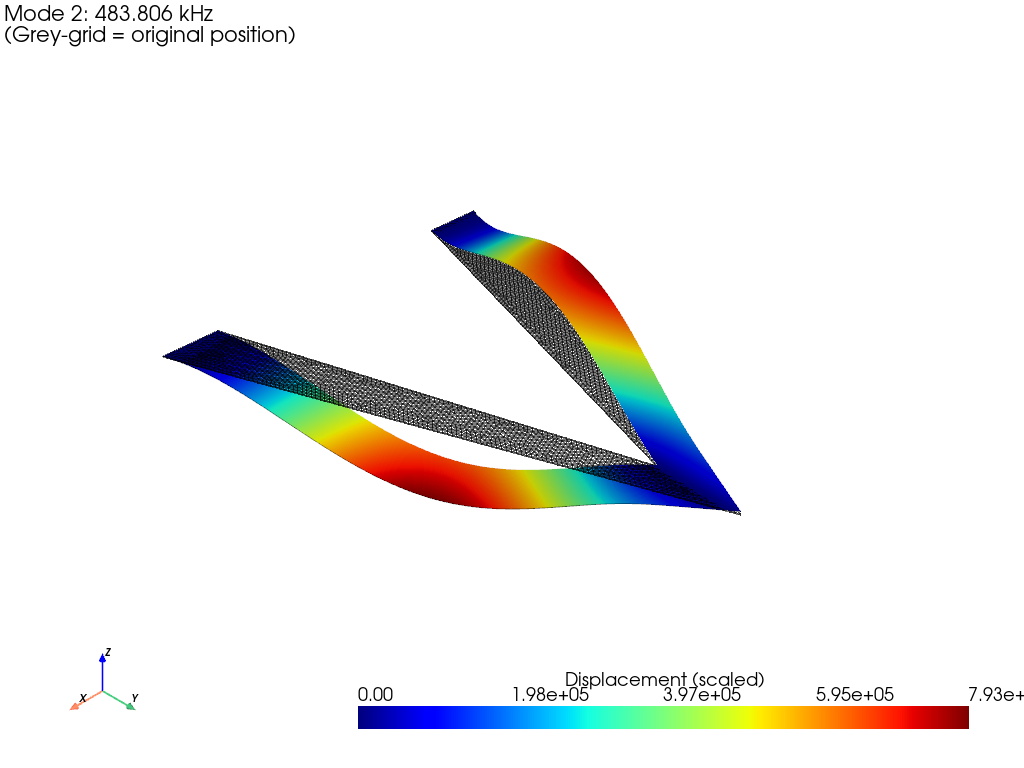

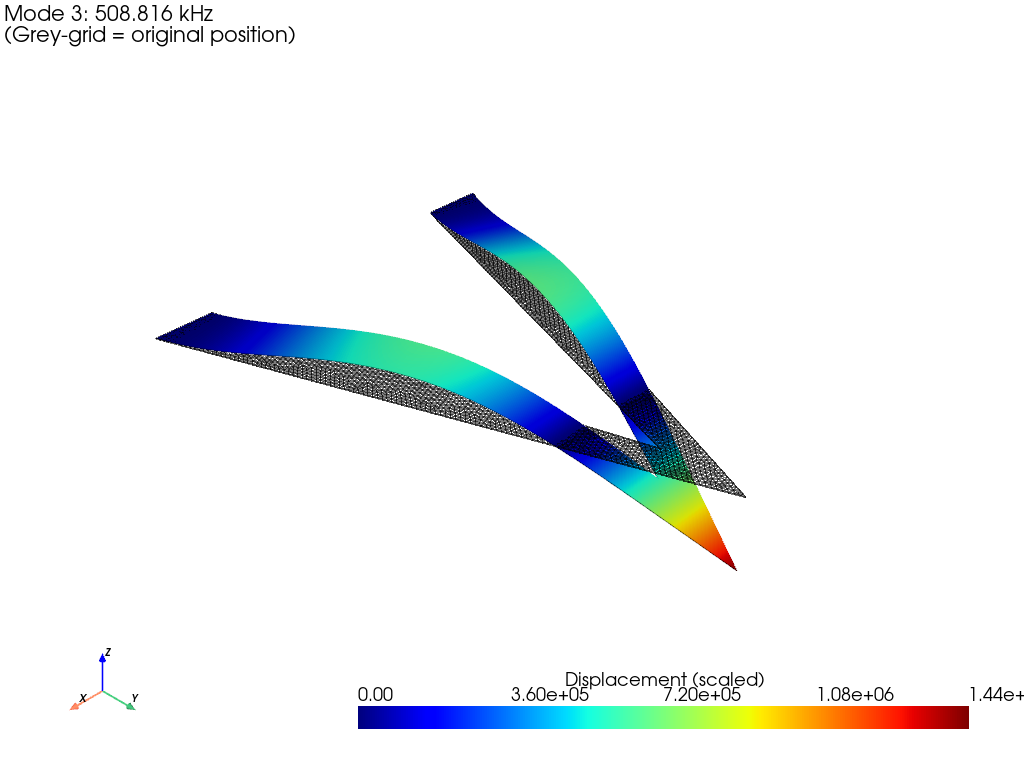

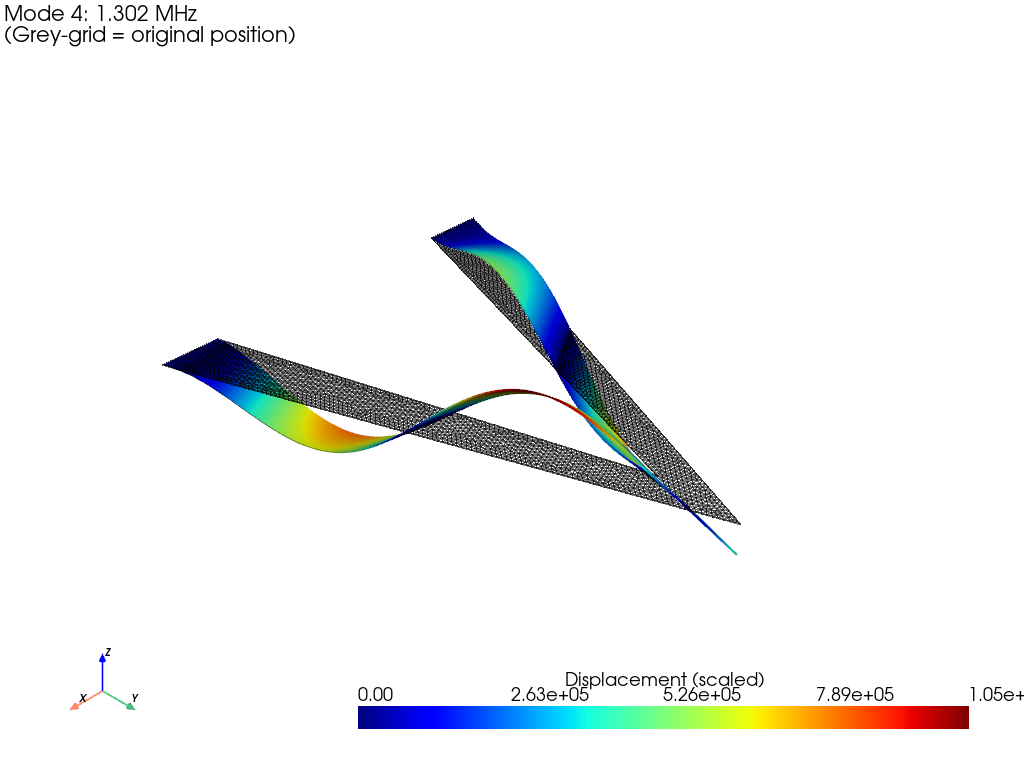

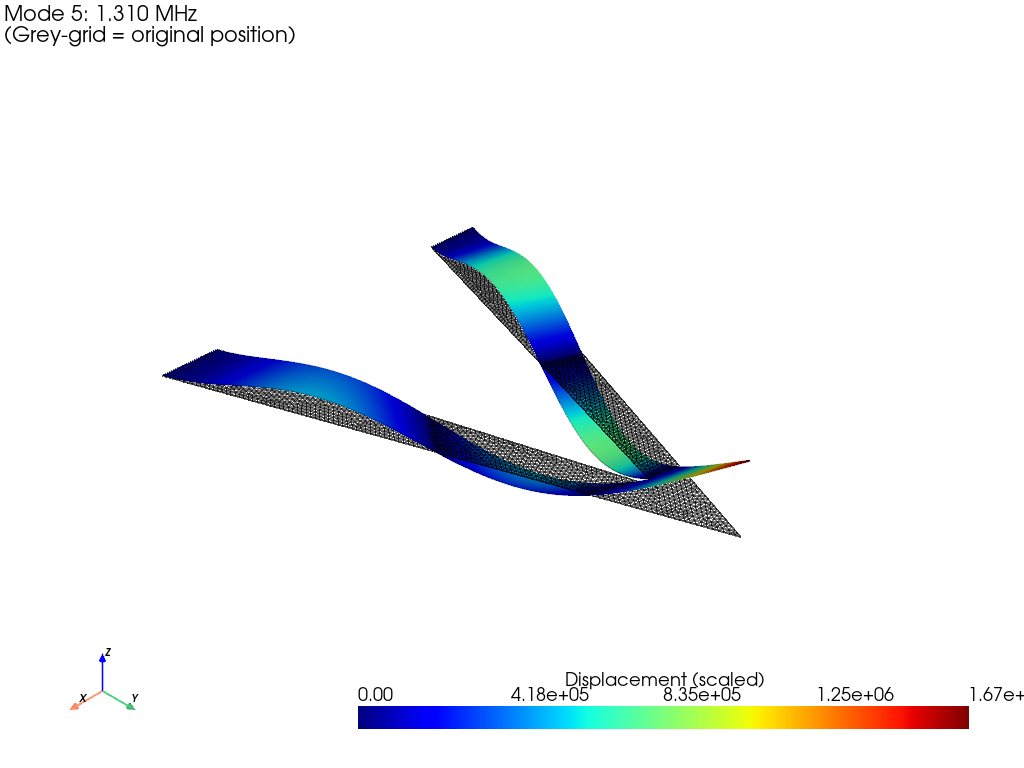

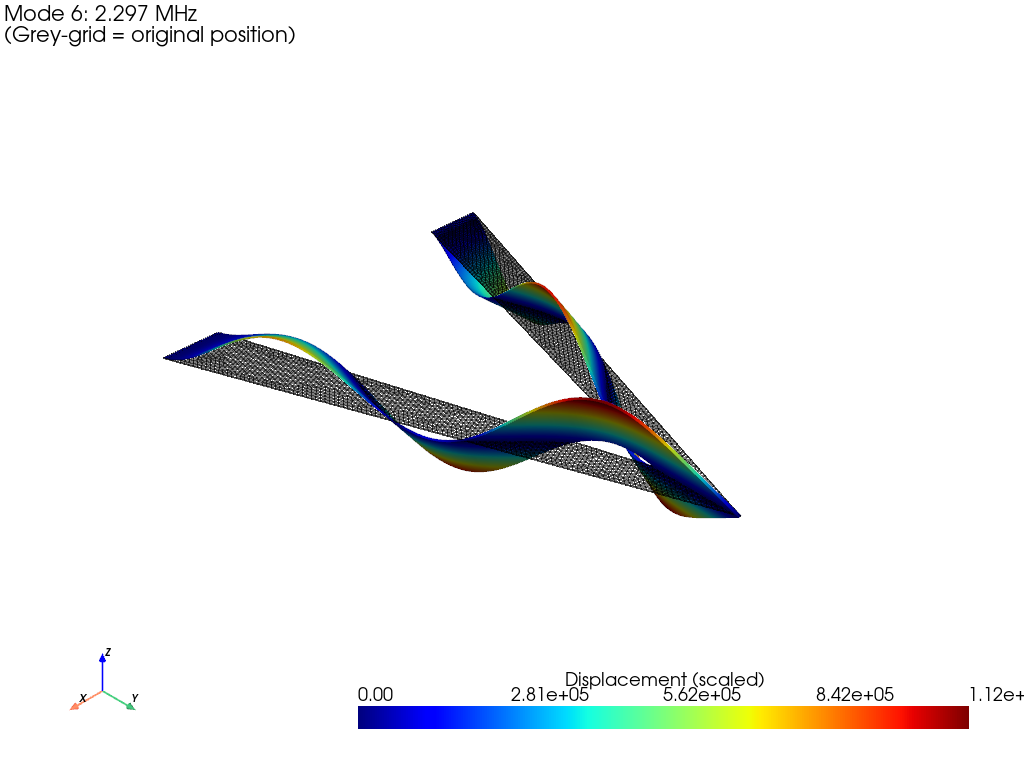

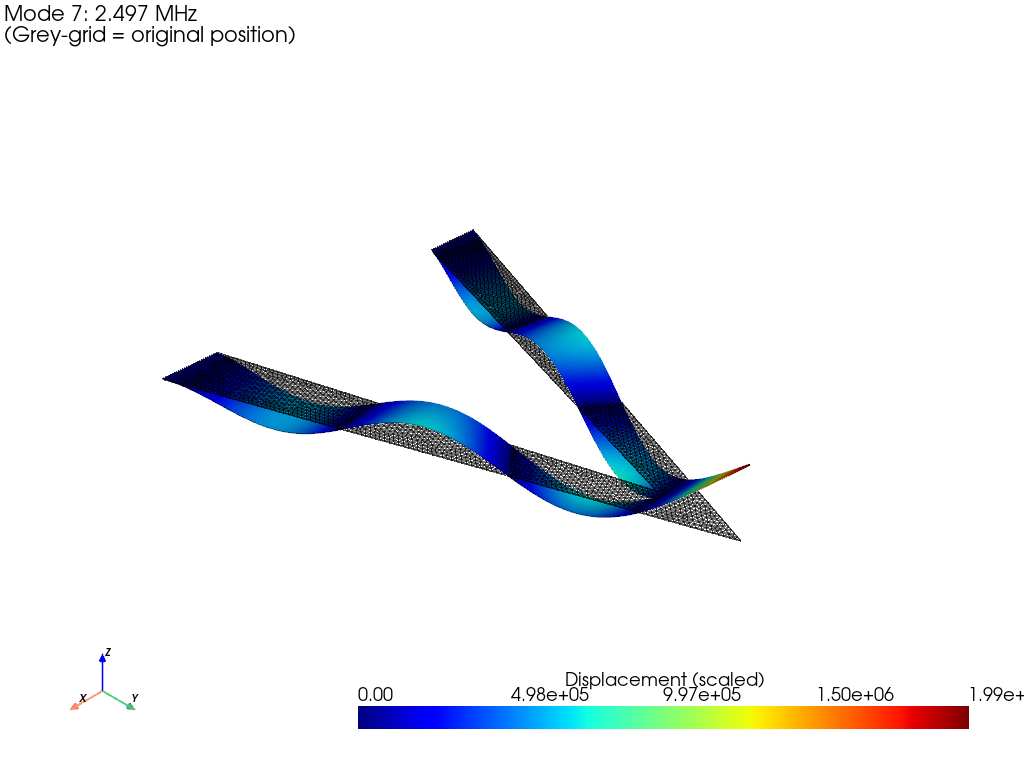

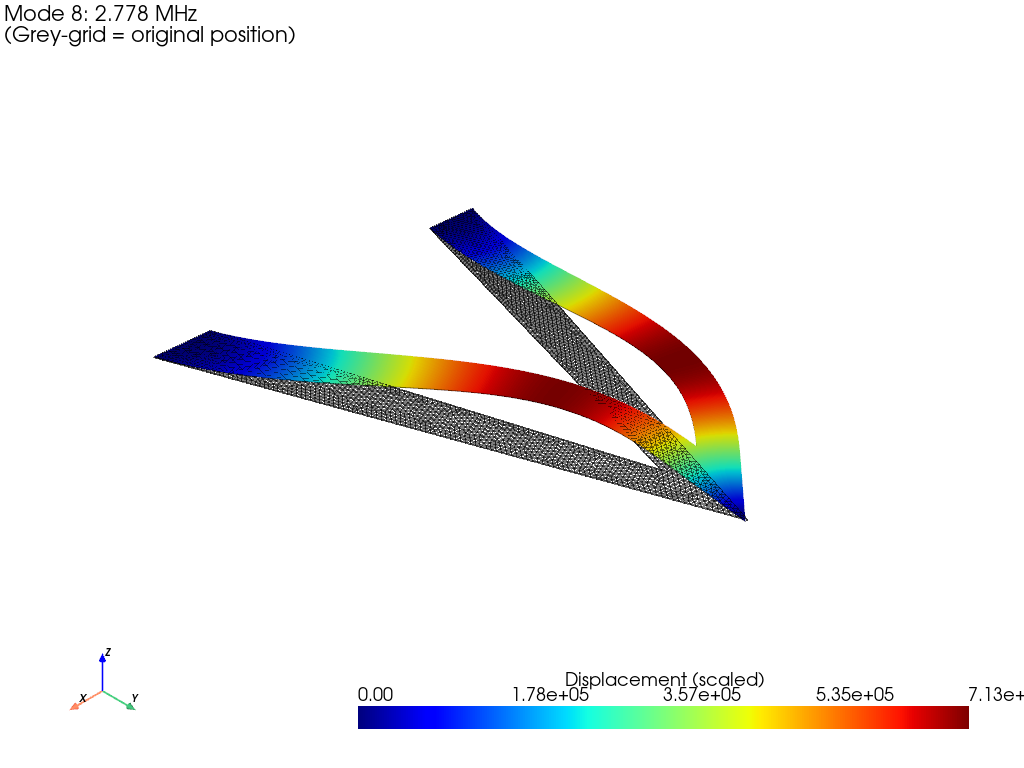

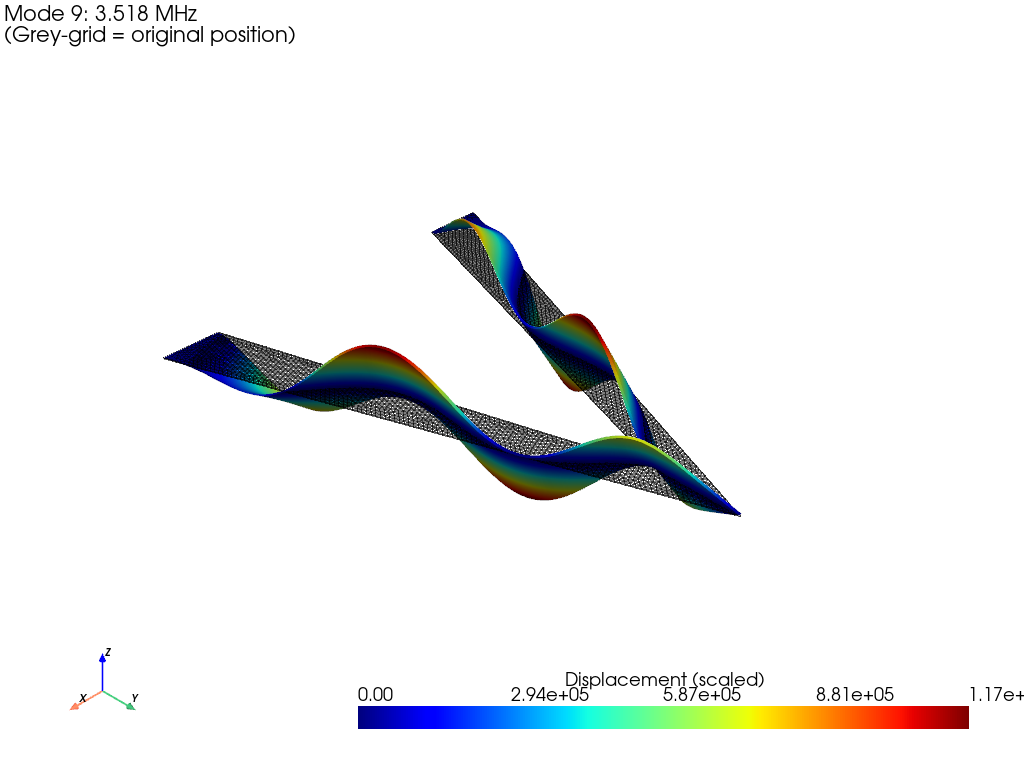

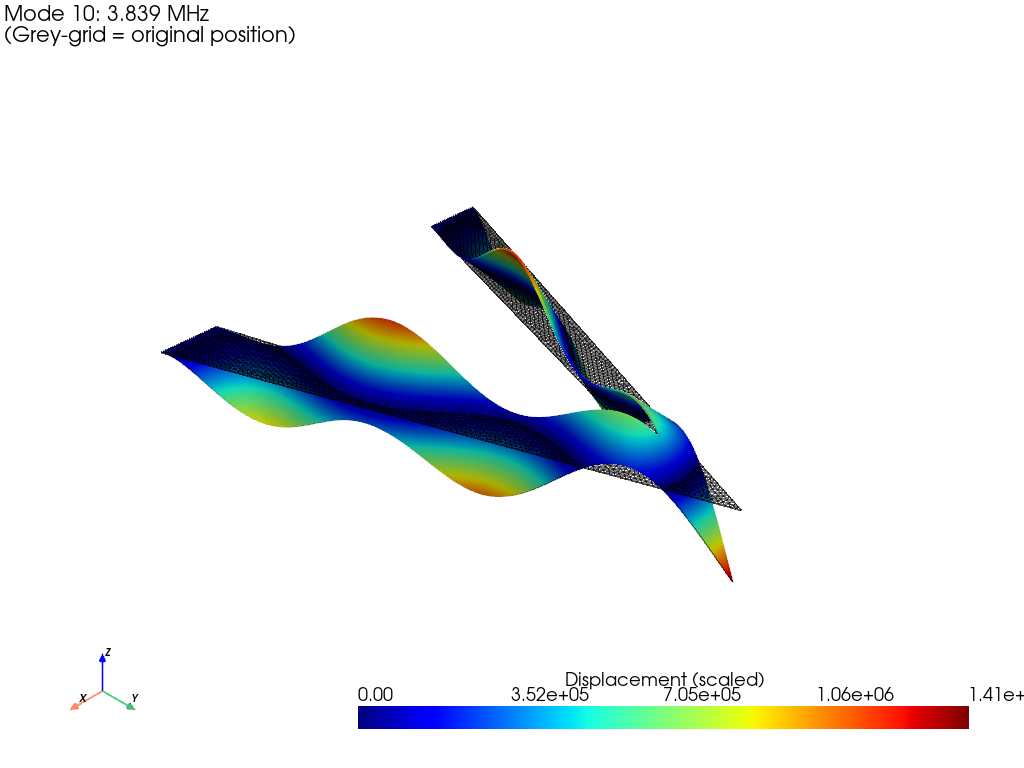

In [12]:
# ------------------------------------------------------------------
# 8) visualisation (deformation + original mesh)
# ------------------------------------------------------------------

# filter: only show modes above 1000 Hz
plot_modes = [m for m in modes if m[0] > 1000]

print(f"Zeige {len(plot_modes)} relevante Moden an.")

for idx, (f0, u0) in enumerate(plot_modes):
    if domain.comm.rank == 0:

        f_label = format_frequency(f0)

        # 1. generate mesh for pyvista
        topology, cell_types, geometry = plot.vtk_mesh(domain)
        grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)

        # 2. attach displacement data to the mesh
        u_vals = u0.x.array.reshape(-1, domain.geometry.dim)
        grid.point_data["u"] = u_vals
        
        # compute magnitude of displacement
        mag_u = np.linalg.norm(u_vals, axis=1)
        grid.point_data["Displacement"] = mag_u
        
        max_disp = np.max(mag_u)
        
        # compute scale factor for visualization
        # scale max displacement to ~15% of characteristic length
        L_char = L / np.tan(alpha) + d / np.sin(alpha)
        if max_disp > 0:
            scale = (L_char * 0.15) / max_disp
        else:
            scale = 1.0

        # 3. create warped mesh
        warped = grid.warp_by_vector("u", factor=scale)

        # 4. Plot
        p = pyvista.Plotter()
        
        # A) Deformed, colored model
        p.add_mesh(warped, 
                   scalars="Displacement", 
                   cmap="jet", 
                   show_scalar_bar=True,
                   scalar_bar_args={"title": "Displacement (scaled)"})

        # B) Original grid (wireframe)
        # attach original (undeformed) mesh as wireframe
        p.add_mesh(grid, style="wireframe", color="black", opacity=0.3, line_width=1)

        p.add_text(f"Mode {idx+1}: {f_label}\n(Grey-grid = original position)", font_size=10)
        p.show_axes()
        p.show()